# Midterm Data Challenge (Oct. 23, 2025)

### Submission

- Deadline: **09:50 AM** (Canvas timestamp strictly enforced).
- Submit your file through "`Canvas` > `Assignment` > `Midterm Exam`".
- Submit only the `.ipynb` file (include your full name in the filename).
- No PDF conversion required.


- Total **30 questions** (Part 1 to Part 5), each worth `1` point.
  - If the required output is missing: `0` point. (no output = invalid)
  - If the code runs but produces incorrect content: up to `0.5` points deduction.

- No *Genertive AI, online search, or references* other than tutorial materials and homework.




## [Part 1] Data Loading and Signal Analysis (5 Problems)

- Refer to the exam handout **[Part 1]** and write your code accordingly.  
- Print all required outputs from **Problem 1-1 to 1-5**.  
⚠️ **Important:** Keep all printed outputs (values, data, and graphs) visible in your notebook before submission.  
- Add as many code cells as needed.  
- Import all necessary Python packages by yourself.

In [1]:
# Import basic packages
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

In [2]:
!git clone https://github.com/ljwg3000/UNT_MEEN.git

Cloning into 'UNT_MEEN'...
remote: Enumerating objects: 6086, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 6086 (delta 9), reused 23 (delta 5), pack-reused 6058 (from 1)
Receiving objects: 100% (6086/6086), 778.91 MiB | 20.50 MiB/s, done.
Resolving deltas: 100% (98/98), done.
Updating files: 100% (4063/4063), done.


In [3]:
data_path = "/content/UNT_MEEN/AI_tutorial/IMS_dataset/1st_test/"

In [4]:
import os

file_list = sorted(os.listdir(data_path))
print("Number of files:", len(file_list))
print(file_list[:3])

Number of files: 344
['2003.10.29.14.39.46', '2003.10.29.14.49.46', '2003.10.29.14.59.46']


In [5]:
for i in range(len(file_list)):
    temp_PATH = data_path + file_list[i]
    temp_DATA = pd.read_csv(temp_PATH, sep='\t', names=['Bearing 1-1', 'Bearing 1-2', 'Bearing 2-1', 'Bearing 2-2',
                                                        'Bearing 3-1', 'Bearing 3-2', 'Bearing 4-1', 'Bearing 4-2'])
    exec(f"Data_{i+1} = temp_DATA")

# Output of problem 1-1
Data_1

,Bearing 1-1,Bearing 1-2,Bearing 2-1,Bearing 2-2,Bearing 3-1,Bearing 3-2,Bearing 4-1,Bearing 4-2
0,-0.115,-0.161,-0.127,-0.137,-0.139,-0.020,-0.054,-0.105
1,-0.007,-0.156,-0.166,-0.139,-0.127,0.015,-0.083,-0.168
2,-0.105,-0.259,-0.166,-0.012,-0.032,-0.122,-0.068,-0.120
3,-0.066,-0.247,-0.122,-0.044,-0.088,-0.085,-0.117,-0.081
4,-0.088,-0.127,-0.056,0.027,-0.115,-0.032,-0.098,-0.134
...,...,...,...,...,...,...,...,...
20475,-0.166,-0.210,-0.186,-0.251,0.073,-0.090,-0.149,-0.107
20476,-0.161,0.042,-0.125,-0.278,-0.291,0.120,-0.095,-0.154
20477,-0.190,-0.186,-0.234,-0.132,-0.198,-0.100,-0.120,-0.183
20478,-0.215,-0.037,-0.325,-0.134,0.005,-0.090,-0.173,-0.098


In [6]:
idx = 70

for i in range(idx):
  exec(f"Normal_{i+1} = Data_{i+1}")

for i in range(idx, len(file_list)):
  exec(f"Abnormal_{i+1-idx} = Data_{i+1}")

NoOfData_Nor = idx
NoOfData_Abn = len(file_list) - idx

# Output of problem 1-2
print(f"Number of Normal   data: {NoOfData_Nor}")
print(f"Number of Abnormal data: {NoOfData_Abn}")

Number of Normal   data: 70
Number of Abnormal data: 274


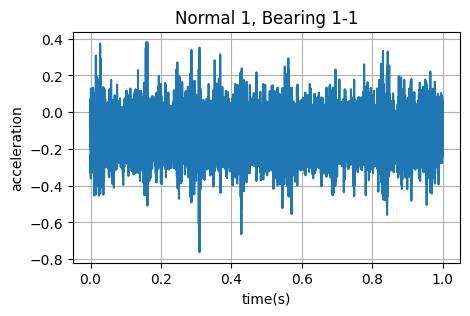

In [7]:
time = np.arange(0, 1, 1/20480)

# Output of problem 1-3
plt.figure(figsize=(5,3))
plt.plot(time , Normal_1.iloc[:,0])
plt.title('Normal 1, Bearing 1-1')
plt.xlabel('time(s)')
plt.ylabel('acceleration')
plt.grid()
plt.show()

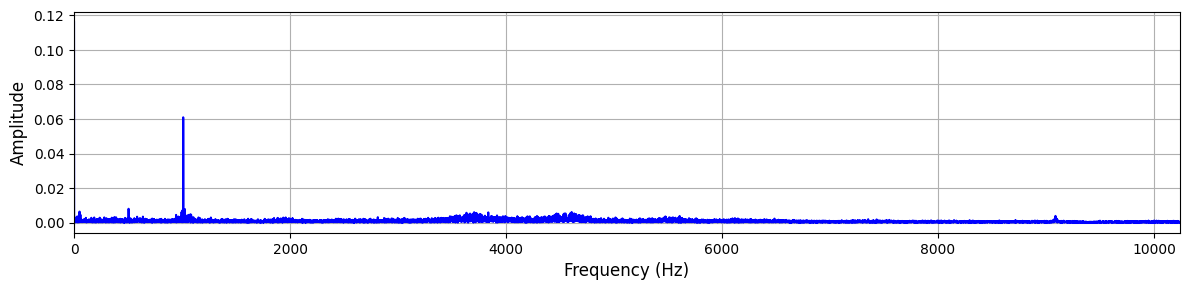

In [8]:
from scipy.fft import fft, fftfreq

t = np.arange(0, 1, 1/20480)
x = Normal_1.iloc[:,0].values

dt = np.mean(np.diff(t))
fs = 1.0 / dt

N = len(x)
X = fft(x)
freq = fftfreq(N, 1/fs)

# single-sided
k_pos = N//2
f_pos = freq[:k_pos]
X_pos = X[:k_pos]

# Amplitude scaling
amp = (2 / N) * np.abs(X_pos)
amp[0] = amp[0] / 2
amp[-1] = amp[-1] / 2

# Output of problem 1-4
plt.figure(figsize=(12,3))
plt.plot(f_pos, amp, 'b-')
plt.xlim(0, fs/2)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid()
plt.tight_layout()
plt.show()

In [9]:
from scipy.signal import find_peaks

# suppose we already have f_pos (Hz) and amp (amplitude spectrum)
peaks, props = find_peaks(amp, height=0.03)

# peak frequencies & amplitudes
peak_freqs = f_pos[peaks]
peak_amps = amp[peaks]

# Output of problem 1-5
print("Peak frequencies:", peak_freqs)
print("Peak amplitudes:", peak_amps)

Peak frequencies: [1011.]
Peak amplitudes: [0.06099643]


.

.

.

## [Part 2] Feature Extraction and Selection (6 Problems)

- Refer to the exam handout **[Part 2]** and write your code accordingly.  
- Print all required outputs from **Problem 2-1 to 2-6**.  
⚠️ **Important:** Keep all printed outputs (values, data, and graphs) visible in your notebook before submission.  
- Add as many code cells as needed.  
- Import all necessary Python packages by yourself.

In [10]:
# We have already defined the NoOfData_Nor and NoOfData_Abn in Part1
NoOfSensor  = 4    # 4 sensors
NoOfFeature = 10   # 10 types of feature

NoOfData_Nor, NoOfData_Abn, NoOfSensor, NoOfFeature

(70, 274, 4, 10)

In [11]:
# Define RMS function
def rms(x):
    return np.sqrt(np.mean(x**2))

In [12]:
# Create empty(0) arrays for time domin feature dataset
TimeFeature_Normal   = np.zeros((NoOfSensor*NoOfFeature , NoOfData_Nor))
TimeFeature_Abnormal = np.zeros((NoOfSensor*NoOfFeature , NoOfData_Abn))

In [13]:
import scipy.stats as sp

for i in range(NoOfData_Nor):

    # Declare temporary data
    exec(f"temp_data1 = Normal_{i+1}")

    # Time domain feature extraction
    for j in range(NoOfSensor):

        # Normal features
        TimeFeature_Normal[NoOfFeature*j+0, i] = np.max(temp_data1.iloc[:,j])
        TimeFeature_Normal[NoOfFeature*j+1, i] = np.min(temp_data1.iloc[:,j])
        TimeFeature_Normal[NoOfFeature*j+2, i] = np.mean(temp_data1.iloc[:,j])
        TimeFeature_Normal[NoOfFeature*j+3, i] = rms(temp_data1.iloc[:,j])
        TimeFeature_Normal[NoOfFeature*j+4, i] = np.var(temp_data1.iloc[:,j])
        TimeFeature_Normal[NoOfFeature*j+5, i] = sp.skew(temp_data1.iloc[:,j])
        TimeFeature_Normal[NoOfFeature*j+6, i] = sp.kurtosis(temp_data1.iloc[:,j])
        TimeFeature_Normal[NoOfFeature*j+7, i] = np.max(temp_data1.iloc[:,j])/rms(temp_data1.iloc[:,j])
        TimeFeature_Normal[NoOfFeature*j+8, i] = rms(temp_data1.iloc[:,j])/np.mean(np.abs(temp_data1.iloc[:,j]))
        TimeFeature_Normal[NoOfFeature*j+9, i] = np.max(temp_data1.iloc[:,j])/np.mean(np.abs(temp_data1.iloc[:,j]))

for i in range(NoOfData_Abn):

    # Declare temporary data
    exec(f"temp_data2 = Abnormal_{i+1}")

    # Time domain feature extraction
    for j in range(NoOfSensor):

        # Abnormal features
        TimeFeature_Abnormal[NoOfFeature*j+0, i] = np.max(temp_data2.iloc[:,j])
        TimeFeature_Abnormal[NoOfFeature*j+1, i] = np.min(temp_data2.iloc[:,j])
        TimeFeature_Abnormal[NoOfFeature*j+2, i] = np.mean(temp_data2.iloc[:,j])
        TimeFeature_Abnormal[NoOfFeature*j+3, i] = rms(temp_data2.iloc[:,j])
        TimeFeature_Abnormal[NoOfFeature*j+4, i] = np.var(temp_data2.iloc[:,j])
        TimeFeature_Abnormal[NoOfFeature*j+5, i] = sp.skew(temp_data2.iloc[:,j])
        TimeFeature_Abnormal[NoOfFeature*j+6, i] = sp.kurtosis(temp_data2.iloc[:,j])
        TimeFeature_Abnormal[NoOfFeature*j+7, i] = np.max(temp_data2.iloc[:,j])/rms(temp_data2.iloc[:,j])
        TimeFeature_Abnormal[NoOfFeature*j+8, i] = rms(temp_data2.iloc[:,j])/np.mean(np.abs(temp_data2.iloc[:,j]))
        TimeFeature_Abnormal[NoOfFeature*j+9, i] = np.max(temp_data2.iloc[:,j])/np.mean(np.abs(temp_data2.iloc[:,j]))

# Output of promblem 2-1
print(TimeFeature_Normal.shape)
print(TimeFeature_Abnormal.shape)

(40, 70)
(40, 274)


In [14]:
TimeFeature = np.concatenate([TimeFeature_Normal, TimeFeature_Abnormal] , axis=1)

# Output of promblem 2-1
print(TimeFeature.shape)

(40, 344)


In [15]:
# Wavelet Transform parameter setting
import pywt
MotherWavelet = pywt.Wavelet('sym5')   # Mother wavelet
Level   = 5                            # Wavelet decomposition level

In [16]:
FreqFeature_Normal   = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData_Nor))
FreqFeature_Abnormal = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData_Abn))

In [17]:
for i in range(NoOfData_Nor):

    # Declare temporary data (only sensor signals)
    exec(f"temp_data1 = Normal_{i+1}")

    # Walvelet decomposition
    Coef1 = pywt.wavedec(temp_data1, MotherWavelet, level=Level, axis=0)

    # Frequency domain feature extraction
    for j in range(NoOfSensor):

        for k in np.arange(Level):
            coef1 = Coef1[Level-k]

            # Normal features
            FreqFeature_Normal[NoOfFeature*j*Level + k*NoOfFeature+0 , i] = np.max(coef1[:,j])
            FreqFeature_Normal[NoOfFeature*j*Level + k*NoOfFeature+1 , i] = np.min(coef1[:,j])
            FreqFeature_Normal[NoOfFeature*j*Level + k*NoOfFeature+2 , i] = np.mean(coef1[:,j])
            FreqFeature_Normal[NoOfFeature*j*Level + k*NoOfFeature+3 , i] = rms(coef1[:,j])
            FreqFeature_Normal[NoOfFeature*j*Level + k*NoOfFeature+4 , i] = np.var(coef1[:,j])
            FreqFeature_Normal[NoOfFeature*j*Level + k*NoOfFeature+5 , i] = sp.skew(coef1[:,j])
            FreqFeature_Normal[NoOfFeature*j*Level + k*NoOfFeature+6 , i] = sp.kurtosis(coef1[:,j])
            FreqFeature_Normal[NoOfFeature*j*Level + k*NoOfFeature+7 , i] = np.max(coef1[:,j])/rms(coef1[:,j])
            FreqFeature_Normal[NoOfFeature*j*Level + k*NoOfFeature+8 , i] = rms(coef1[:,j])/np.mean(np.abs(coef1[:,j]))
            FreqFeature_Normal[NoOfFeature*j*Level + k*NoOfFeature+9 , i] = np.max(coef1[:,j])/np.mean(np.abs(coef1[:,j]))

for i in range(NoOfData_Abn):

    # Declare temporary data (only sensor signals)
    exec(f"temp_data2 = Abnormal_{i+1}")

    # Walvelet decomposition
    Coef2 = pywt.wavedec(temp_data2, MotherWavelet, level=Level, axis=0)

    # Frequency domain feature extraction
    for j in range(NoOfSensor):

        for k in np.arange(Level):
            coef2 = Coef2[Level-k]

            # Abnormal features
            FreqFeature_Abnormal[NoOfFeature*j*Level + k*NoOfFeature+0 , i] = np.max(coef2[:,j])
            FreqFeature_Abnormal[NoOfFeature*j*Level + k*NoOfFeature+1 , i] = np.min(coef2[:,j])
            FreqFeature_Abnormal[NoOfFeature*j*Level + k*NoOfFeature+2 , i] = np.mean(coef2[:,j])
            FreqFeature_Abnormal[NoOfFeature*j*Level + k*NoOfFeature+3 , i] = rms(coef2[:,j])
            FreqFeature_Abnormal[NoOfFeature*j*Level + k*NoOfFeature+4 , i] = np.var(coef2[:,j])
            FreqFeature_Abnormal[NoOfFeature*j*Level + k*NoOfFeature+5 , i] = sp.skew(coef2[:,j])
            FreqFeature_Abnormal[NoOfFeature*j*Level + k*NoOfFeature+6 , i] = sp.kurtosis(coef2[:,j])
            FreqFeature_Abnormal[NoOfFeature*j*Level + k*NoOfFeature+7 , i] = np.max(coef2[:,j])/rms(coef2[:,j])
            FreqFeature_Abnormal[NoOfFeature*j*Level + k*NoOfFeature+8 , i] = rms(coef2[:,j])/np.mean(np.abs(coef2[:,j]))
            FreqFeature_Abnormal[NoOfFeature*j*Level + k*NoOfFeature+9 , i] = np.max(coef2[:,j])/np.mean(np.abs(coef2[:,j]))

# Output of promblem 2-2
print(FreqFeature_Normal.shape)
print(FreqFeature_Abnormal.shape)

(200, 70)
(200, 274)


In [18]:
FreqFeature = np.concatenate([FreqFeature_Normal, FreqFeature_Abnormal] , axis=1)

# Output of promblem 2-2
FreqFeature.shape

(200, 344)

In [19]:
# Complete FeatureData by concatenating TimeFeature and FreqFeature
Features = np.concatenate([TimeFeature,FreqFeature] , axis=0)
FeatureData = pd.DataFrame(Features)

# Output of promblem 2-3
FeatureData

,0,1,2,3,4,5,6,7,8,9,...,334,335,336,337,338,339,340,341,342,343
0,0.381000,0.491000,0.381000,0.425000,0.366000,0.515000,0.408000,0.422000,0.366000,0.422000,...,0.396000,0.381000,0.457000,0.464000,0.400000,0.398000,0.466000,0.383000,0.581000,0.466000
1,-0.762000,-0.771000,-0.767000,-0.664000,-0.691000,-0.715000,-0.823000,-0.664000,-0.720000,-0.818000,...,-0.679000,-0.679000,-0.774000,-0.640000,-0.627000,-0.771000,-0.710000,-0.652000,-0.833000,-0.667000
2,-0.116000,-0.116770,-0.116820,-0.116614,-0.116991,-0.118466,-0.118108,-0.115636,-0.116159,-0.116695,...,-0.116271,-0.117123,-0.117749,-0.117508,-0.115828,-0.118558,-0.116599,-0.117174,-0.117335,-0.118129
3,0.151065,0.150689,0.151046,0.149873,0.151285,0.153410,0.153723,0.153132,0.152186,0.154528,...,0.152039,0.152470,0.153236,0.152023,0.149818,0.153056,0.152232,0.152676,0.152958,0.151715
4,0.009365,0.009072,0.009168,0.008863,0.009200,0.009501,0.009681,0.010078,0.009668,0.010261,...,0.009597,0.009529,0.009616,0.009303,0.009029,0.009370,0.009579,0.009580,0.009629,0.009063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,-0.006335,0.127461,-0.057008,0.138340,-0.093098,-0.097832,0.096656,-0.032065,-0.050157,-0.258219,...,0.140830,0.037586,-0.069092,-0.018022,0.044314,0.040003,-0.148626,-0.014060,-0.156044,0.261046
236,-0.236814,-0.019028,-0.130976,0.040049,-0.085404,-0.185666,-0.158881,-0.340139,-0.262272,0.121149,...,-0.325118,-0.277779,-0.203476,-0.237809,-0.292361,0.173286,-0.092916,-0.144907,0.194934,0.219354
237,3.312001,3.254421,2.704754,3.126547,2.918013,2.984072,2.757109,2.756620,2.786512,2.768862,...,2.754132,3.221914,2.499256,2.452969,2.856266,3.519180,3.239534,3.044197,3.200969,3.386300
238,1.217933,1.259338,1.249333,1.260839,1.229821,1.249638,1.250292,1.221047,1.241086,1.263704,...,1.220021,1.234696,1.236618,1.241399,1.238803,1.258561,1.237978,1.254866,1.270538,1.273895


.

.

.


In [20]:
import seaborn           as sb
import scipy.stats       as sp

Normal_FeatureData   = FeatureData.iloc[:,:NoOfData_Nor]
Abnormal_FeatureData = FeatureData.iloc[:,NoOfData_Nor:]

print(Normal_FeatureData.shape)
print(Abnormal_FeatureData.shape)

(240, 70)
(240, 274)


In [22]:
NoOfFeature = FeatureData.shape[0] # Number of feature: 240

P_value = np.zeros((NoOfFeature , 2))

# t-Test (Result: p-value)
for i in np.arange(NoOfFeature):

    T_test       = np.array(sp.ttest_ind(Normal_FeatureData.iloc[i,:] , Abnormal_FeatureData.iloc[i,:]))
    P_value[i,0] = i          # Index of feature (0~239)
    P_value[i,1] = T_test[1]  # P-value

P_value = pd.DataFrame(P_value, columns=['No.', 'P-value'])
P_value_Rank = P_value.sort_values(['P-value'], ascending=True)

# Output of promblem 2-4
P_value_Rank

,No.,P-value
114,114.0,2.797969e-122
113,113.0,2.107759e-120
14,14.0,3.530181e-119
18,18.0,1.000985e-102
94,94.0,2.317491e-98
...,...,...
209,209.0,9.655033e-01
167,167.0,9.721697e-01
197,197.0,9.733362e-01
199,199.0,9.886937e-01


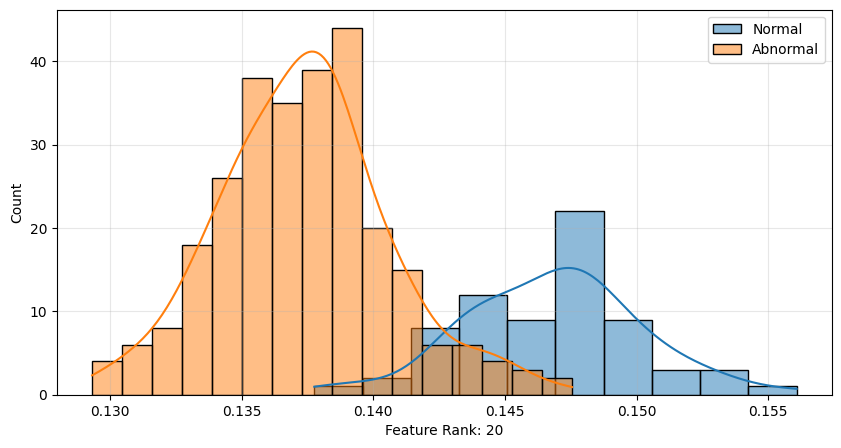

In [23]:
# P-value Rank (0 ~ 239)
FeatureRank = 19

# Output of promblem 2-5
plt.figure(figsize=(10,5))
sb.histplot(Normal_FeatureData.iloc[int(P_value_Rank.iloc[FeatureRank,0])  ,:], kde=True, label = 'Normal')
sb.histplot(Abnormal_FeatureData.iloc[int(P_value_Rank.iloc[FeatureRank,0]),:], kde=True, label = 'Abnormal')
plt.legend(loc='best', fontsize=10)
plt.xlabel(f'Feature Rank: {FeatureRank+1}')
plt.grid(alpha=0.3)
plt.show()

In [24]:
Rank = 20  # Select number of rank

Normal   = np.zeros((Rank,NoOfData_Nor))
Abnormal = np.zeros((Rank,NoOfData_Abn))

for i in range(Rank):

    index         = int(P_value_Rank.iloc[i,0])
    Normal[i,:]   = Normal_FeatureData.iloc[index,:].values
    Abnormal[i,:] = Abnormal_FeatureData.iloc[index,:].values

FeatureSelected = pd.DataFrame(np.concatenate([Normal, Abnormal] , axis=1))

# Output of promblem 2-6
FeatureSelected

,0,1,2,3,4,5,6,7,8,9,...,334,335,336,337,338,339,340,341,342,343
0,0.009857,0.009613,0.009687,0.009625,0.009532,0.010286,0.010141,0.010296,0.010793,0.010079,...,0.008203,0.008854,0.008437,0.008703,0.008498,0.008776,0.008482,0.008262,0.008789,0.008672
1,0.099283,0.098085,0.098435,0.098111,0.097649,0.101432,0.100734,0.101513,0.103893,0.100395,...,0.090582,0.094303,0.091911,0.093322,0.092195,0.093681,0.092116,0.090899,0.093803,0.093153
2,0.007821,0.007643,0.007789,0.007708,0.007890,0.008298,0.008262,0.008441,0.008352,0.008679,...,0.007293,0.007778,0.007605,0.007440,0.007433,0.007667,0.007488,0.007498,0.007570,0.007402
3,1.175470,1.171236,1.170976,1.175893,1.174073,1.179353,1.175089,1.179741,1.180685,1.184159,...,1.168549,1.175011,1.171746,1.168015,1.173478,1.170738,1.170377,1.169945,1.173004,1.169502
4,0.005371,0.005495,0.005449,0.005459,0.005443,0.005883,0.005640,0.006046,0.005730,0.006457,...,0.005032,0.005286,0.005331,0.005012,0.005009,0.005298,0.005074,0.005181,0.005297,0.005209
5,0.145823,0.145814,0.146914,0.145247,0.146319,0.149296,0.148491,0.147879,0.148013,0.148726,...,0.143581,0.145569,0.146198,0.145811,0.144438,0.146846,0.144997,0.145937,0.145317,0.145012
6,0.073293,0.074141,0.073816,0.073884,0.073774,0.076703,0.075102,0.077760,0.075699,0.080359,...,0.070942,0.072708,0.073012,0.070798,0.070799,0.072796,0.071229,0.071980,0.072782,0.072172
7,0.008237,0.007939,0.007951,0.007884,0.008319,0.008654,0.008728,0.009296,0.008299,0.009487,...,0.008441,0.008521,0.008296,0.008557,0.007962,0.008614,0.008537,0.008311,0.008888,0.008356
8,0.003860,0.003938,0.003963,0.003695,0.004099,0.004053,0.003992,0.004365,0.004206,0.004597,...,0.004145,0.003865,0.003903,0.003794,0.003858,0.003947,0.003931,0.003847,0.004001,0.003634
9,0.090771,0.089114,0.089196,0.088795,0.091208,0.093031,0.093428,0.096425,0.091101,0.097404,...,0.091875,0.092364,0.091123,0.092509,0.089230,0.092851,0.092408,0.091170,0.094306,0.091412


.

.

.

## [Part 3] Data Visualization (3 Problems)

- Refer to the exam handout **[Part 3]** and write your code accordingly.  
- Print all required outputs from **Problem 3-1 to 3-3**.  
⚠️ **Important:** Keep all printed outputs (values, data, and graphs) visible in your notebook before submission.  
- Add as many code cells as needed.  
- Import all necessary Python packages by yourself.

In [ ]:
# Use the FeatureSelected from Part2.

In [25]:
# Standardize the FeatureData
from sklearn.preprocessing import StandardScaler

FeatureSelected_std = StandardScaler().fit_transform(FeatureSelected.T)
                             ######## You must standardize the TRANPOSED FeatureSelected! #######
# Output of promblem 3-1
print(FeatureSelected_std.shape)
FeatureSelected_std

(344, 20)


array([[ 1.35647619,  1.37469616,  0.60026159, ...,  0.42275932,
         0.7166723 ,  0.73219534],
       [ 1.1033208 ,  1.13703174,  0.33279846, ...,  0.15316041,
         0.05285746,  0.06857314],
       [ 1.18017731,  1.2063305 ,  0.55220907, ..., -0.25286794,
         0.74175278,  0.75958327],
       ...,
       [-0.29941475, -0.28891281,  0.11483572, ..., -1.1380255 ,
        -0.5157795 , -0.51242323],
       [ 0.24790191,  0.28727903,  0.22273753, ..., -0.53673507,
        -0.82418652, -0.8281791 ],
       [ 0.12593701,  0.15840658, -0.02927571, ..., -1.53932005,
        -0.63310866, -0.63441172]])

In [26]:
from sklearn.manifold import TSNE
import time

dim          = 2
time_start   = time.time()
tsne         = TSNE(n_components=dim, verbose=1, perplexity=25, n_iter=500, random_state=777)
tsne_results = tsne.fit_transform(FeatureSelected_std)

print( '\n\n t-SNE done! Time elapsed: {} seconds\n\n'.format(time.time() - time_start ))

# Output of problem 3-2
pd.DataFrame(tsne_results)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 76 nearest neighbors...
[t-SNE] Indexed 344 samples in 0.000s...
[t-SNE] Computed neighbors for 344 samples in 0.040s...
[t-SNE] Computed conditional probabilities for sample 344 / 344
[t-SNE] Mean sigma: 0.794769
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.418770
[t-SNE] KL divergence after 500 iterations: 0.685857


 t-SNE done! Time elapsed: 0.7094330787658691 seconds




,0,1
0,19.684078,-4.295155
1,18.860838,-4.430186
2,19.255608,-4.339622
3,17.968227,-4.543110
4,20.805988,-3.743342
...,...,...
339,12.444061,-6.180603
340,11.565617,-5.446409
341,12.008311,-5.323779
342,12.801527,-4.713027


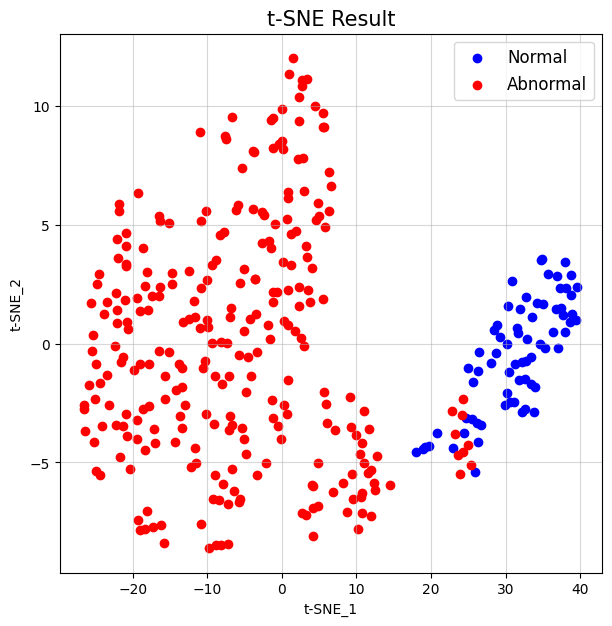

In [27]:
NoOfData = NoOfData_Nor

# Output of problem 3-3
plt.figure(figsize=(7,7))
plt.scatter(tsne_results[:NoOfData,0], tsne_results[:NoOfData,1], marker='o', label='Normal', c='b')
plt.scatter(tsne_results[NoOfData:,0], tsne_results[NoOfData:,1], marker='o', label='Abnormal', c='r')
plt.title('t-SNE Result', fontsize=15)
plt.grid(alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel('t-SNE_1')
plt.ylabel('t-SNE_2')

plt.show()

## [Part 4] MLP-Based Grid Search for Classification (6 Problems)

- Refer to the exam handout **[Part 4]** and write your code accordingly.  
- Print all required outputs from **Problem 4-1 to 4-6**.  
⚠️ **Important:** Keep all printed outputs (values, data, and graphs) visible in your notebook before submission.
  - For problems where no explicit output is requested (Problem 4-3, 4-4), *only the code will be evaluated*.
  - For machine learning tasks, *there is no single correct performance*, as long as your code runs correctly and prints the result, it will be graded as correct.
- Add as many code cells as needed.  
- Import all necessary Python packages by yourself.

In [28]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
# Use the FeatureSelected from Part2.

In [29]:
NoOfData   = NoOfData_Nor # Let's set the NoOfData as the number of normal data (NoOfData_Nor) here.

NormalSet   = FeatureSelected_std[:NoOfData , :]
AbnormalSet = FeatureSelected_std[NoOfData: , :]

NormalSet.shape, AbnormalSet.shape

((70, 20), (274, 20))

In [30]:
from sklearn.model_selection    import train_test_split

# Designate test data ratio
TestData_Ratio = 0.2

TrainData_Nor, TestData_Nor = train_test_split(NormalSet  , test_size=TestData_Ratio, random_state=777)
TrainData_Abn, TestData_Abn = train_test_split(AbnormalSet, test_size=TestData_Ratio, random_state=777)

print(TrainData_Nor.shape, TestData_Nor.shape)
print(TrainData_Abn.shape, TestData_Abn.shape)

(56, 20) (14, 20)
(219, 20) (55, 20)


In [31]:
TrainLabel_Nor = np.zeros((TrainData_Nor.shape[0],2))
TrainLabel_Abn = np.ones( (TrainData_Abn.shape[0],2))
TestLabel_Nor  = np.zeros((TestData_Nor.shape[0],2))
TestLabel_Abn  = np.ones( (TestData_Abn.shape[0],2))

TrainLabel_Nor[:,0] = 1  # [1,0]: Normal
TrainLabel_Abn[:,0] = 0  # [0,1]: Abnormal
TestLabel_Nor[:,0]  = 1  # [1,0]: Normal
TestLabel_Abn[:,0]  = 0  # [0,1]: Abnormal

print(TrainLabel_Nor.shape, TestLabel_Nor.shape)
print(TrainLabel_Abn.shape, TestLabel_Abn.shape)

(56, 2) (14, 2)
(219, 2) (55, 2)


In [32]:
TrainData  = np.concatenate([TrainData_Nor , TrainData_Abn ], axis=0)
TestData   = np.concatenate([TestData_Nor  , TestData_Abn  ], axis=0)
TrainLabel = np.concatenate([TrainLabel_Nor, TrainLabel_Abn], axis=0)
TestLabel  = np.concatenate([TestLabel_Nor , TestLabel_Abn ], axis=0)

# Output of problem 4-1
print(TrainData.shape,  TestData.shape)
print(TrainLabel.shape, TestLabel.shape)

(275, 20) (69, 20)
(275, 2) (69, 2)


In [33]:
# Hyperparameters for grid search
param_ActFn = ['relu', 'selu']
param_Layer = [1, 2]

# Fixed hyperparameters
noOfNeuron   = 10
Epoch        = 200
LearningRate = 0.001

# Calculate the number of cases
NoOfCases = len(param_ActFn) * len(param_Layer)

# Output of problem 4-2
NoOfCases

4

In [34]:
# Create an empty dataframe to store the accuracy results
Accuracy_df = pd.DataFrame(np.zeros(shape=(NoOfCases , 3)),
                           columns=['Activation Function', 'Num of hidden layer', 'Accuracy'])

In [35]:
# Code of problem 4-3
def MLP_model(input_data, temp_actfn, temp_layer):
    keras.backend.clear_session()  # Clearing the Keras backend session (initiating variables)

    model = keras.Sequential()
    model.add(keras.layers.InputLayer(shape=(input_data.shape[1],)))  # Input Layer

    # Adding hidden layers according to the input value of `temp_layer`
    for i in range(temp_layer):
        model.add(keras.layers.Dense(units=noOfNeuron, activation=temp_actfn, name=f'Hidden{i+1}'))  # Hidden Layers

    model.add(keras.layers.Dense(units=2, activation='softmax', name='Output'))  # Output Layer

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LearningRate),
                  loss=keras.losses.CategoricalCrossentropy(),
                  metrics=['accuracy'])
    return model

In [36]:
# Code of problem 4-4
# Callback 1: CheckProcess
EpochForPrint = 10

class CheckProcess(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        keras.callbacks.Callback()
        if epoch%EpochForPrint == 0:
            print("{} Epochs Train Acc. : {:.2f}%  ".format(epoch, logs["accuracy"]*100))

In [37]:
# Code of problem 4-4
# Callback 2: Early Stopping
EalryStop = keras.callbacks.EarlyStopping(
    monitor="accuracy", patience=30, restore_best_weights=True)

In [38]:
# Initialize a count value to store the performance of each model
cnt = 0

# Iterate through all possible combinations of activation functions, hidden layers, and learning rates
for temp_actfn in param_ActFn:          # Select each activation function in the list
    for temp_layer in param_Layer:      # Select each hidden layer configuration in the list

            print(f"\n[Case {cnt+1}] Activation: '{temp_actfn}', Num of layers: {temp_layer}")

            # Create, train, and validate a temporary MLP model with the current combination of hyperparameters
            temp_model = MLP_model(TrainData, temp_actfn, temp_layer)
            temp_model.fit(TrainData, TrainLabel, epochs=Epoch, verbose=0, callbacks=[CheckProcess(), EalryStop])
            Loss, Accuracy = temp_model.evaluate(TestData,  TestLabel, verbose=0)

            # Store the performance (accuracy) of the temporary model in the dataframe
            Accuracy_df.iloc[cnt, :] = [temp_actfn, temp_layer, Accuracy]
            cnt += 1


[Case 1] Activation: 'relu', Num of layers: 1
0 Epochs Train Acc. : 24.36%  
10 Epochs Train Acc. : 90.18%  
20 Epochs Train Acc. : 97.45%  
30 Epochs Train Acc. : 97.45%  
40 Epochs Train Acc. : 97.45%  
50 Epochs Train Acc. : 97.82%  
60 Epochs Train Acc. : 97.82%  
70 Epochs Train Acc. : 97.82%  


/tmp/ipython-input-2682654048.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'relu' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  Accuracy_df.iloc[cnt, :] = [temp_actfn, temp_layer, Accuracy]



[Case 2] Activation: 'relu', Num of layers: 2
0 Epochs Train Acc. : 66.18%  
10 Epochs Train Acc. : 97.82%  
20 Epochs Train Acc. : 97.45%  
30 Epochs Train Acc. : 97.82%  
40 Epochs Train Acc. : 98.18%  
50 Epochs Train Acc. : 98.18%  
60 Epochs Train Acc. : 98.18%  

[Case 3] Activation: 'selu', Num of layers: 1
0 Epochs Train Acc. : 59.27%  
10 Epochs Train Acc. : 96.00%  
20 Epochs Train Acc. : 97.09%  
30 Epochs Train Acc. : 97.45%  
40 Epochs Train Acc. : 97.82%  
50 Epochs Train Acc. : 97.45%  
60 Epochs Train Acc. : 97.45%  
70 Epochs Train Acc. : 97.45%  

[Case 4] Activation: 'selu', Num of layers: 2
0 Epochs Train Acc. : 90.18%  
10 Epochs Train Acc. : 97.09%  
20 Epochs Train Acc. : 97.45%  
30 Epochs Train Acc. : 98.18%  
40 Epochs Train Acc. : 98.18%  
50 Epochs Train Acc. : 98.55%  
60 Epochs Train Acc. : 98.55%  


In [39]:
# Output of problem 4-5
Accuracy_df

,Activation Function,Num of hidden layer,Accuracy
0,relu,1.0,0.956522
1,relu,2.0,0.956522
2,selu,1.0,0.956522
3,selu,2.0,0.956522


In [40]:
# Sort the Accuracy_df by 'Accuracy' column in descending order
Accuracy_df_sorted = Accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Output of problem 4-6
print("[Best case]\nActivation Function: " + Accuracy_df_sorted.iloc[0, 0] +
      "\nHidden Layers: {}\n\nAccuracy: {:.2f}".format(Accuracy_df_sorted.iloc[0, 1], Accuracy_df_sorted.iloc[0, 2]))

[Best case]
Activation Function: relu
Hidden Layers: 1.0

Accuracy: 0.96


.

.

.

## [Part 5] AE-Based Unsupervised Fault Detection (10 Problems)

- Refer to the exam handout **[Part 5]** and write your code accordingly.  
- Print all required outputs from **Problem 5-1 to 5-10**.  
⚠️ **Important:** Keep all printed outputs (values, data, and graphs) visible in your notebook before submission.
  - For problems where no explicit output is requested (Problem 5-2, 5-4, 5-5), *only the code will be evaluated*.
  - For machine learning tasks, *there is no single correct performance*, as long as your code runs correctly and prints the result, it will be graded as correct.
- Add as many code cells as needed.  
- Import all necessary Python packages by yourself.

In [ ]:
# Use the FeatureSelected, NormalSet, AbnormalSet from Part2 and Part 4.

In [41]:
TestData_Ratio = 0.2
TrainData_Nor, ValidData_Nor = train_test_split(NormalSet  , test_size=TestData_Ratio, random_state=777)

print(TrainData_Nor.shape, ValidData_Nor.shape)

(56, 20) (14, 20)


In [42]:
TrainData  = TrainData_Nor
ValidData  = ValidData_Nor
TestData   = np.concatenate([NormalSet  , AbnormalSet], axis=0)

# Output of problem 5-1
print(TrainData.shape, ValidData_Nor.shape, TestData.shape)

(56, 20) (14, 20) (344, 20)


In [43]:
# Code of problem 5-2
def AE_model(input_data):
    keras.backend.clear_session() # clearing the Keras backend session (initiating variables)

    model = keras.Sequential()
    model.add(keras.layers.InputLayer(input_shape = (input_data.shape[1],) ))                               # Input Layer
    model.add(keras.layers.Dense(units = 14, activation = keras.activations.relu, name = 'Encoder_1'))      # Encoder
    model.add(keras.layers.Dense(units = 9 , activation = keras.activations.relu, name = 'Encoder_2'))      # Encoder
    model.add(keras.layers.Dense(units = 4 , activation = keras.activations.relu, name = 'LatentSpace'))    # Bottle neck
    model.add(keras.layers.Dense(units = 9 , activation = keras.activations.relu, name = 'Decoder_1'))      # Decoder
    model.add(keras.layers.Dense(units = 14, activation = keras.activations.relu, name = 'Decoder_2'))      # Decoder
    model.add(keras.layers.Dense(units = input_data.shape[1], activation = keras.activations.linear, name = 'Output')) # Output (Reconstruction)

    model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.001), # Optimizer
                  loss = keras.losses.MeanSquaredError())                   # Loss for reconstruction error between input and output

    return model

In [44]:
AE = AE_model(TrainData)

# Output of problem 5-3
AE.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Encoder_1 (Dense)               │ (None, 14)             │           294 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_2 (Dense)               │ (None, 9)              │           135 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LatentSpace (Dense)             │ (None, 4)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_1 (Dense)               │ (None, 9)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_2 (Dense)               │ (None, 14)             │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 20)             │           300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 954 (3.73 KB)

 Trainable params: 954 (3.73 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Code of problem 5-4
# Callback 1: CheckProcess
EpochForPrint = 10
class CheckProcess(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        keras.callbacks.Callback()
        if epoch%EpochForPrint == 0:
            print("[{} Epochs] Validation loss: {:.4f}  ".format(epoch, logs['val_loss']))

In [46]:
# Code of problem 5-4
# Callback 2: Early Stopping
EalryStop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=30, restore_best_weights=True)

In [47]:
# Code of problem 5-5
TraingHistory = AE.fit(TrainData, TrainData,
                       validation_data=(ValidData, ValidData),
                       epochs=500, verbose=0,
                       callbacks=[EalryStop, CheckProcess()])

[0 Epochs] Validation loss: 3.7483  
[10 Epochs] Validation loss: 3.3099  
[20 Epochs] Validation loss: 2.4084  
[30 Epochs] Validation loss: 1.3626  
[40 Epochs] Validation loss: 0.7417  
[50 Epochs] Validation loss: 0.3762  
[60 Epochs] Validation loss: 0.2339  
[70 Epochs] Validation loss: 0.1887  
[80 Epochs] Validation loss: 0.1751  
[90 Epochs] Validation loss: 0.1683  
[100 Epochs] Validation loss: 0.1663  
[110 Epochs] Validation loss: 0.1646  
[120 Epochs] Validation loss: 0.1634  
[130 Epochs] Validation loss: 0.1615  
[140 Epochs] Validation loss: 0.1605  
[150 Epochs] Validation loss: 0.1590  
[160 Epochs] Validation loss: 0.1578  
[170 Epochs] Validation loss: 0.1565  
[180 Epochs] Validation loss: 0.1561  
[190 Epochs] Validation loss: 0.1560  
[200 Epochs] Validation loss: 0.1558  
[210 Epochs] Validation loss: 0.1552  
[220 Epochs] Validation loss: 0.1540  
[230 Epochs] Validation loss: 0.1530  
[240 Epochs] Validation loss: 0.1523  
[250 Epochs] Validation loss: 0.1510

In [48]:
# Define a function calculating the Mean Squared Errors (MSEs)
def recon_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean((X - X_pred)**2, axis=1)

err_train = recon_error(AE, TrainData)      # MSEs of training data (normal)
err_valid = recon_error(AE, ValidData)      # MSEs of validation data (normal)
err_test  = recon_error(AE, TestData )      # MSEs of test data (nor + abn)

# Output of problem 5-6
print("TrainData Error: {:.2f}\n".format(err_train.mean()) +
      "ValidData Error: {:.2f}\n\n".format(err_valid.mean()) +
      " Test_Tot Error: {:.2f}\n".format(err_test.mean()))

TrainData Error: 0.09
ValidData Error: 0.11

 Test_Tot Error: 0.72



In [49]:
TestLabel = np.zeros(TestData.shape[0])
TestLabel[NoOfData_Nor:] = 1

AUC (ROC): 0.978



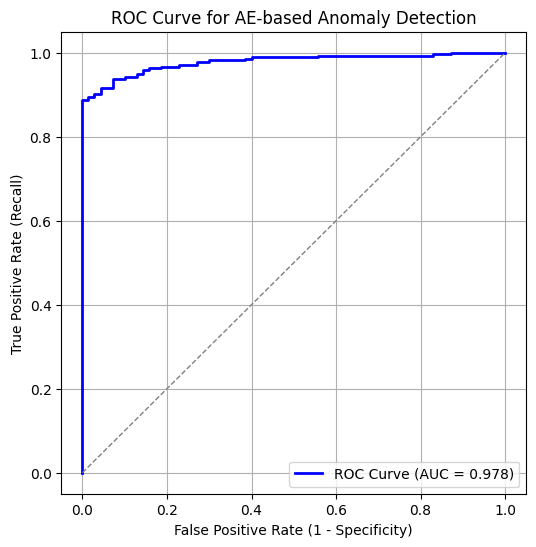

In [50]:
from sklearn.metrics import roc_curve, auc

# ROC/AUC
fpr, tpr, ths_roc = roc_curve(TestLabel, err_test)
roc_auc = auc(fpr, tpr)
print(f"AUC (ROC): {roc_auc:.3f}\n")

# Output of problem 5-7
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color='gray', linestyle='--', lw=1)  # random guess line
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve for AE-based Anomaly Detection')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [51]:
j_scores      = tpr - fpr
max_index     = np.argmax(j_scores)
Threshold_ROC = ths_roc[max_index]

# Output of problem 5-8
print(f"Threshold_ROC: {Threshold_ROC:.3f}\n")

Threshold_ROC: 0.250



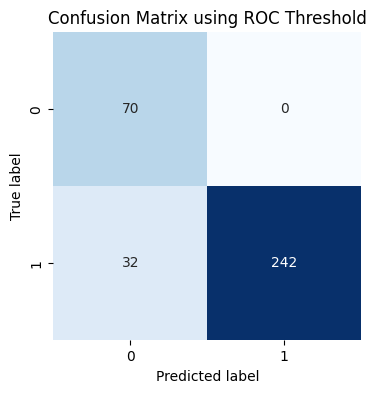

In [52]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

Predict_ROC = np.where(err_test > Threshold_ROC, 1, 0)
cm_AE = confusion_matrix(TestLabel, Predict_ROC)

# Output of problem 5-9
plt.figure(figsize=(4, 4))
sns.heatmap(cm_AE, annot=True, fmt='d', cmap=plt.cm.Blues, cbar=False, square=True)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix using ROC Threshold")
plt.show()

In [53]:
from sklearn import metrics

accuracy_AE  = metrics.accuracy_score( TestLabel, Predict_ROC)
precision_AE = metrics.precision_score(TestLabel, Predict_ROC)
recall_AE    = metrics.recall_score(   TestLabel, Predict_ROC)
f1_score_AE  = metrics.f1_score(       TestLabel, Predict_ROC)

# Output of problem 5-10
print(f"Accuracy : {accuracy_AE:.2f}")
print(f"Precision: {precision_AE:.2f}")
print(f"Recall   : {recall_AE:.2f}")
print(f"F1 Score : {f1_score_AE:.2f}")

Accuracy : 0.91
Precision: 1.00
Recall   : 0.88
F1 Score : 0.94
